In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

import os
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, activations, losses, optimizers, callbacks
from tensorflow.keras.utils import plot_model

In [43]:
data_dir = "asl_dataset"
Images_size =(96,96)

In [10]:
os.listdir(data_dir)

['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [44]:
images =[] #x
labels =[] #y

for label_name in os.listdir(data_dir):
    label_path = os.path.join(data_dir,label_name)
    if os.path.isdir(label_path):
        for file in os.listdir(label_path):
            file_path=os.path.join(label_path,file)
            img = Image.open(file_path)
            img = img.convert("RGB")

            img = img.resize(Images_size)

            img_array = np.array(img)/255
            images.append(img_array)
            labels.append(label_name)

In [45]:
len(images)

2515

In [46]:
type(images), type(labels)

(list, list)

In [47]:
images = np.array(images)
labels = np.array(labels)

In [48]:
images.shape

(2515, 96, 96, 3)

In [49]:
le = LabelEncoder()
y = le.fit_transform(labels)

In [50]:
y

array([ 0,  0,  0, ..., 35, 35, 35], dtype=int64)

In [ ]:
len(y)

Text(0.5, 1.0, 's')

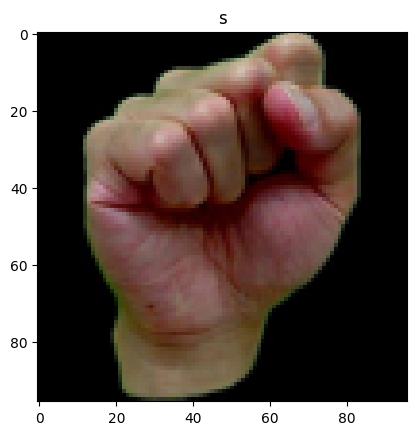

In [54]:
i = np.random.randint(0,2515)

plt.imshow(images[i])
plt.title(labels[i])

In [55]:
X_train , X_test , y_train , y_test = train_test_split(images , y , test_size=0.2,random_state=5)

In [73]:

input = layers.Input(shape=(96, 96, 3))

cnn1 = layers.Conv2D(64, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.1))(input)
cnn2 = layers.Conv2D(64, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.1))(cnn1)
bn1 = layers.BatchNormalization()(cnn2)
drop1 = layers.Dropout(0.5)(bn1)
max1 = layers.MaxPool2D((2, 2))(drop1)

cnn3 = layers.Conv2D(128, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.1))(input)
cnn4 = layers.Conv2D(128, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.1))(cnn3)
bn2 = layers.BatchNormalization()(cnn4)
drop2 = layers.Dropout(0.5)(bn2)
max2 = layers.MaxPool2D((2, 2))(drop2)

concat1 = layers.Concatenate()([max1, max2])

gap = layers.GlobalAveragePooling2D()(concat1)

fc1 = layers.Dense(128, activation=layers.PReLU())(gap) 
fc2 = layers.Dense(128, activation=layers.LeakyReLU())(gap)



add = layers.Add()([fc1, fc2]) 
drop3 = layers.Dropout(0.5)(add) 

output = layers.Dense(36, activation='softmax', name='output')(drop3)

model_functional = keras.Model(inputs=input, outputs=output)

model_functional.summary()


Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 96, 96, 3)]  0           []                               
                                                                                                  
 conv2d_21 (Conv2D)             (None, 96, 96, 64)   1792        ['input_2[0][0]']                
                                                                                                  
 conv2d_23 (Conv2D)             (None, 96, 96, 128)  3584        ['input_2[0][0]']                
                                                                                                  
 conv2d_22 (Conv2D)             (None, 96, 96, 64)   36928       ['conv2d_21[0][0]']              
                                                                                            

In [74]:
adam = optimizers.Adam(learning_rate=0.002)
model_functional.compile(
    optimizer = adam,
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [75]:
y_train.shape

(2012,)

In [77]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5)

history = model_functional.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 50,
    batch_size = 16,
    callbacks = [es,rlr]
)

Epoch 1/50


101/101 [==============================] - 65s 643ms/step - loss: 3.4509 - accuracy: 0.0609 - val_loss: 3.8914 - val_accuracy: 0.0744 - lr: 0.0020
Epoch 2/50
101/101 [==============================] - 84s 838ms/step - loss: 3.0061 - accuracy: 0.1212 - val_loss: 4.2712 - val_accuracy: 0.0670 - lr: 0.0020
Epoch 3/50
101/101 [==============================] - 75s 739ms/step - loss: 2.6248 - accuracy: 0.1740 - val_loss: 3.1489 - val_accuracy: 0.0918 - lr: 0.0020
Epoch 4/50
101/101 [==============================] - 69s 680ms/step - loss: 2.3269 - accuracy: 0.2486 - val_loss: 3.1697 - val_accuracy: 0.1166 - lr: 0.0020
Epoch 5/50
101/101 [==============================] - 67s 664ms/step - loss: 2.0848 - accuracy: 0.3176 - val_loss: 3.4323 - val_accuracy: 0.1017 - lr: 0.0020
Epoch 6/50
101/101 [==============================] - 69s 679ms/step - loss: 1.9970 - accuracy: 0.3207 - val_loss: 3.0749 - val_accuracy: 0.1290 - lr: 0.0020
Epoch 7/50
101/101 [==============================] - 66s 658ms

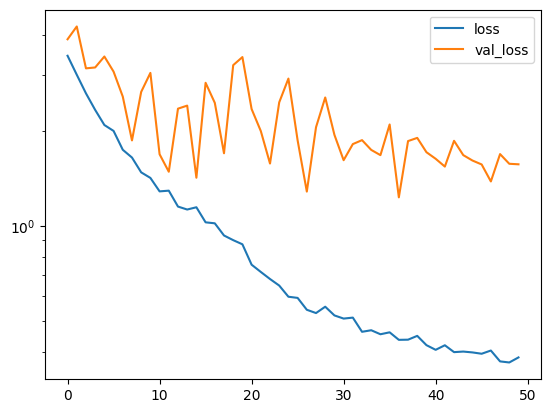

In [78]:
plt.plot(history.history['loss'], label = 'loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.legend()
plt.yscale('log')

In [79]:
from sklearn.metrics import accuracy_score, confusion_matrix


y_pred = model_functional.predict(X_test)
y_pred_argmax = np.argmax(y_pred, axis=1)
accuracy_score(y_test, y_pred_argmax)

16/16 [==============================] - 4s 216ms/step


0.46123260437375746